<a href="https://colab.research.google.com/github/nattapongbam/Rainfall-Forecasting-ChiangMai/blob/main/Project_XGBoost_rainfall.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression
import seaborn as sns

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Project_Timeseries_Rainfall/Files_weather/weather_0001_not_normal_f1.csv')

In [4]:
df.head()

,Unnamed: 0,wind_dir,wind_speed,temp,heat_index,pressure,preci,vis,rain
0,2013-01-01,297.0,1.10,22.25,24.45,977.15,5.5,13249.0,0.81
1,2013-02-01,289.0,1.25,24.85,25.85,973.75,0.1,13433.0,1.13
2,2013-03-01,334.0,0.50,28.10,28.10,972.40,0.0,7735.0,0.55
3,2013-04-01,176.0,1.40,31.70,32.50,970.50,0.4,12949.0,0.04
4,2013-05-01,193.0,1.80,29.90,32.60,970.30,100.0,18706.0,2.90


In [5]:
df.rename(columns={'Unnamed: 0':'date'}, inplace=True)

In [6]:
df.head(10)

,date,wind_dir,wind_speed,temp,heat_index,pressure,preci,vis,rain
0,2013-01-01,297.0,1.10,22.25,24.45,977.15,5.5,13249.0,0.81
1,2013-02-01,289.0,1.25,24.85,25.85,973.75,0.1,13433.0,1.13
2,2013-03-01,334.0,0.50,28.10,28.10,972.40,0.0,7735.0,0.55
3,2013-04-01,176.0,1.40,31.70,32.50,970.50,0.4,12949.0,0.04
4,2013-05-01,193.0,1.80,29.90,32.60,970.30,100.0,18706.0,2.90
5,2013-06-01,200.0,1.50,29.00,32.10,968.50,43.4,19294.0,1.32
6,2013-07-01,190.0,1.10,28.00,31.20,968.40,213.2,19254.0,8.80
7,2013-08-01,242.0,0.80,27.40,30.40,969.30,315.4,18986.0,9.66
8,2013-09-01,267.0,0.90,27.40,30.40,970.90,287.0,18387.0,9.19
9,2013-10-01,320.0,0.70,26.20,27.90,975.20,127.2,13429.0,3.98


In [7]:
df_fe = df.copy()

In [8]:
df_fe['date_dt'] = pd.to_datetime(df_fe['date'], format='%Y-%m-%d')
df_fe['year'] = df_fe['date_dt'].dt.year
df_fe['month'] = df_fe['date_dt'].dt.month
df_fe['year_idx'] = df_fe['year'] - df_fe['year'].min()

df_fe['month_sin'] = np.sin(2 * np.pi * df_fe['month'] / 12)
df_fe['month_cos'] = np.cos(2 * np.pi * df_fe['month'] / 12)

In [9]:
type(df_fe['date_dt'][0])

pandas._libs.tslibs.timestamps.Timestamp

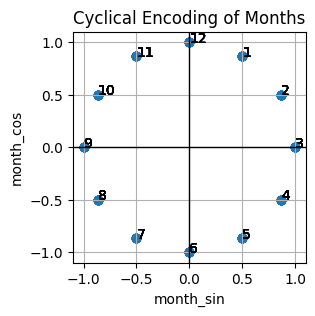

In [10]:
plt.figure(figsize=(3,3))
plt.scatter(df_fe['month_sin'], df_fe['month_cos'])
for i, m in enumerate(df_fe['month']):
    plt.annotate(m, (df_fe['month_sin'][i], df_fe['month_cos'][i]))
plt.title('Cyclical Encoding of Months')
plt.xlabel('month_sin')
plt.ylabel('month_cos')
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.grid(True)
plt.show()

# check ตัวแปร

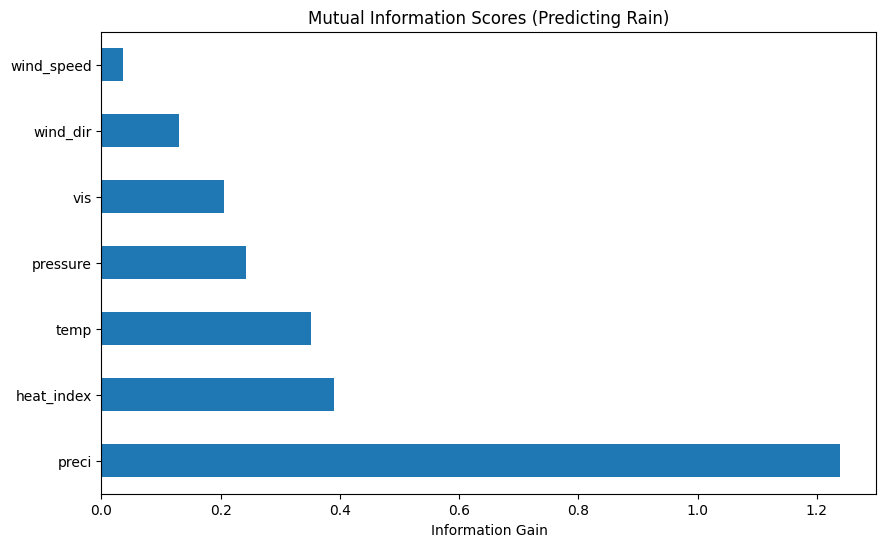

preci         1.238061
heat_index    0.389414
temp          0.351700
pressure      0.242658
vis           0.204905
wind_dir      0.129622
wind_speed    0.036030
Name: MI Scores, dtype: float64


In [11]:
X = df.drop(columns=['rain', 'date']) # ตัวแปรต้น (ลบคอลัมน์ที่ไม่เกี่ยวข้องออก)
y = df['rain']                        # ตัวแปรตาม (Target)

mi_scores = mutual_info_regression(X, y, discrete_features=False, random_state=42)

mi_results = pd.Series(mi_scores, name="MI Scores", index=X.columns)
mi_results = mi_results.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
mi_results.plot(kind='barh')
plt.title("Mutual Information Scores (Predicting Rain)")
plt.xlabel("Information Gain")
plt.show()

print(mi_results)

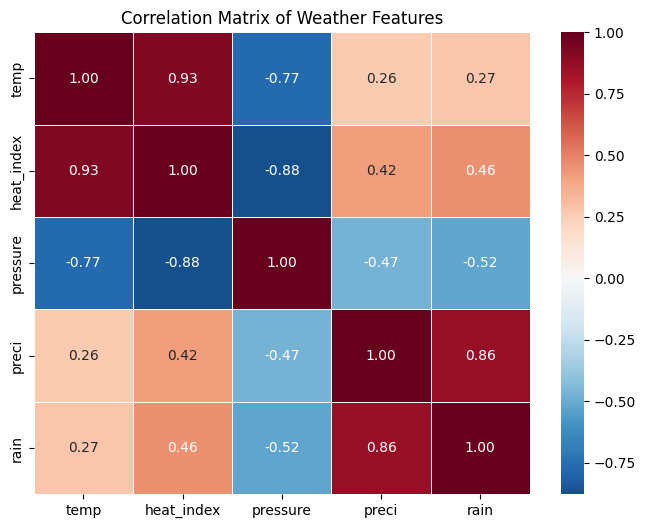

In [12]:
cols = ['temp', 'heat_index', 'pressure', 'preci', 'rain']
corr_matrix = df[cols].corr()

# 2. สร้างกราฟ Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap='RdBu_r',
            center=0,
            linewidths=0.5)

plt.title('Correlation Matrix of Weather Features')
plt.show()

In [13]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

def compute_vif(df, features):
    X = df[features].copy()

    X_with_const = add_constant(X)

    vif_data = pd.DataFrame()
    vif_data["feature"] = X_with_const.columns
    vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i)
                       for i in range(len(X_with_const.columns))]

    # กรองเอาแถวที่เป็น 'const' ออก
    return vif_data[vif_data['feature'] != 'const'].sort_values('VIF', ascending=False)

feature_list = ['temp','pressure', 'heat_index', 'preci', 'rain']

vif_results = compute_vif(df, feature_list)
print(vif_results)

      feature        VIF
3  heat_index  15.499946
1        temp   9.366533
2    pressure   4.845556
5        rain   4.521993
4       preci   3.951553


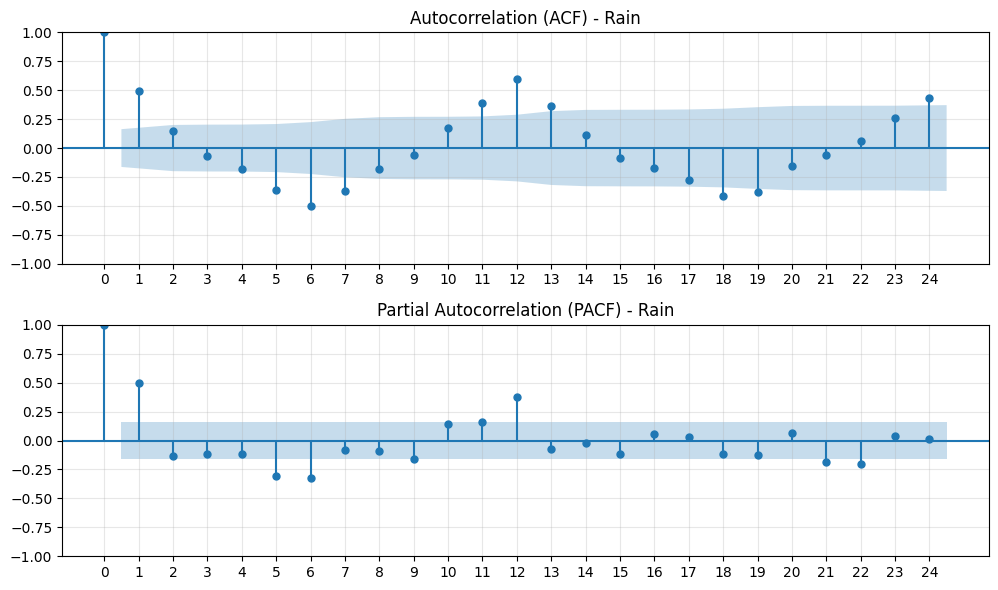

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))

# Plot ACF
plot_acf(df['rain'], lags=24, ax=ax1) # ดูย้อนหลัง 24 ช่วงเวลา
ax1.set_xticks(np.arange(25))
ax1.set_title('Autocorrelation (ACF) - Rain')
ax1.grid(True, alpha=0.3)

# Plot PACF
plot_pacf(df['rain'], lags=24, ax=ax2, method='yw')
ax2.set_xticks(np.arange(25))
ax2.set_title('Partial Autocorrelation (PACF) - Rain')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

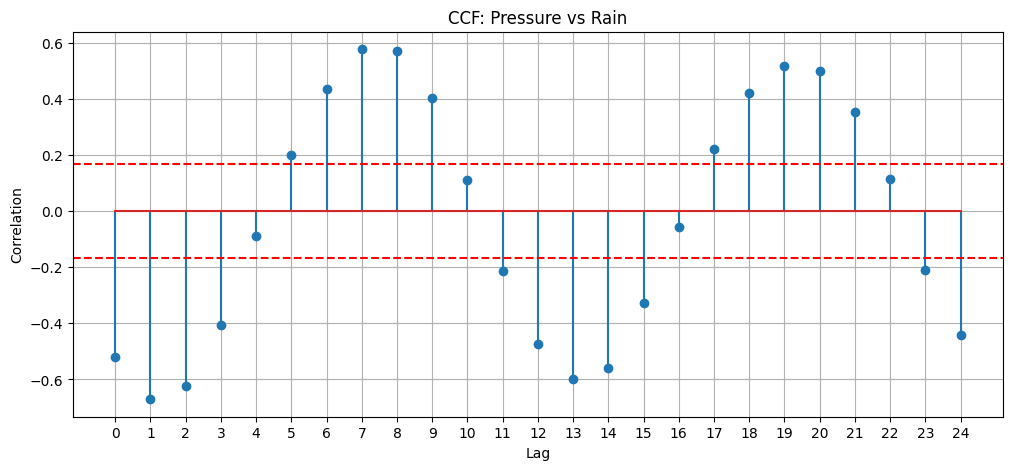

In [15]:
import numpy as np
from statsmodels.tsa.stattools import ccf

def plot_ccf_custom(x, y, title="Cross-Correlation", nlags=24):
    correlation = ccf(y, x, adjusted=False)[:nlags+1]

    lags = np.arange(len(correlation))

    plt.figure(figsize=(12, 5))
    plt.stem(lags, correlation)
    plt.xticks(lags)

    # วาดเส้นนัยสำคัญ (Significance levels) ประมาณ 95% Confidence Interval
    plt.axhline(y=2/np.sqrt(len(x)), color='r', linestyle='--')
    plt.axhline(y=-2/np.sqrt(len(x)), color='r', linestyle='--')

    plt.title(title)
    plt.xlabel('Lag')
    plt.ylabel('Correlation')
    plt.grid(True)
    plt.show()

plot_ccf_custom(df['pressure'], df['rain'], title="CCF: Pressure vs Rain")  #'temp','pressure', 'heat_index', 'preci', 'rain'

# XG Boost variable



In [16]:
df_fe

,date,wind_dir,wind_speed,temp,heat_index,pressure,preci,vis,rain,date_dt,year,month,year_idx,month_sin,month_cos
0,2013-01-01,297.0,1.10,22.25,24.45,977.15,5.5,13249.0,0.81,2013-01-01,2013,1,0,5.000000e-01,8.660254e-01
1,2013-02-01,289.0,1.25,24.85,25.85,973.75,0.1,13433.0,1.13,2013-02-01,2013,2,0,8.660254e-01,5.000000e-01
2,2013-03-01,334.0,0.50,28.10,28.10,972.40,0.0,7735.0,0.55,2013-03-01,2013,3,0,1.000000e+00,6.123234e-17
3,2013-04-01,176.0,1.40,31.70,32.50,970.50,0.4,12949.0,0.04,2013-04-01,2013,4,0,8.660254e-01,-5.000000e-01
4,2013-05-01,193.0,1.80,29.90,32.60,970.30,100.0,18706.0,2.90,2013-05-01,2013,5,0,5.000000e-01,-8.660254e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,2024-08-01,230.0,1.50,27.60,31.20,970.80,232.2,18911.0,7.67,2024-08-01,2024,8,11,-8.660254e-01,-5.000000e-01
140,2024-09-01,249.0,1.50,27.50,31.00,969.80,389.6,19995.0,12.75,2024-09-01,2024,9,11,-1.000000e+00,-1.836970e-16
141,2024-10-01,277.0,1.50,27.70,30.90,974.00,149.6,19993.0,4.66,2024-10-01,2024,10,11,-8.660254e-01,5.000000e-01
142,2024-11-01,304.0,1.50,25.40,26.50,976.30,48.8,19999.0,1.57,2024-11-01,2024,11,11,-5.000000e-01,8.660254e-01


In [17]:
df1 = df_fe.copy()

In [18]:
df1['preci']
df1['rain_lag1'] = df1['rain'].shift(1)
df1['rain_lag12'] = df1['rain'].shift(12)
df1['pressure_lag1'] = df1['pressure'].shift(1)
# df1['pressure_lag1'] = df1['pressure'].shift(2)
df1['heat_index_lag1'] = df1['heat_index'].shift(1)
df1['vis_lag1'] = df1['vis'].shift(1)
df1['preci_ma3'] = df1['preci'].shift(1).rolling(window=3).mean()

In [19]:
# df1['rain'] = np.log1p(df1['rain'])
# df1['rain_lag1'] = np.log1p(df1['rain_lag1'])
# df1['rain_lag12'] = np.log1p(df1['rain_lag12'])

In [20]:
df_xg1 = df1[['month_sin', 'month_cos', 'year_idx', 'heat_index', 'heat_index_lag1', 'pressure', 'pressure_lag1', 'preci_ma3', 'vis_lag1', 'rain_lag1', 'rain_lag12','rain']].copy()

In [21]:
df_xg1.dropna(inplace=True)
df_xg1 = df_xg1.reset_index(drop=True)
df_xg1

,month_sin,month_cos,year_idx,heat_index,heat_index_lag1,pressure,pressure_lag1,preci_ma3,vis_lag1,rain_lag1,rain_lag12,rain
0,5.000000e-01,8.660254e-01,1,24.3,22.8,978.6,977.6,81.800000,10863.0,0.86,0.81,0.00
1,8.660254e-01,5.000000e-01,1,25.6,24.3,974.2,978.6,39.400000,10275.0,0.00,1.13,0.00
2,1.000000e+00,6.123234e-17,1,28.0,25.6,973.6,974.2,9.333333,15850.0,0.00,0.55,0.19
3,8.660254e-01,-5.000000e-01,1,30.4,28.0,972.0,973.6,2.066667,9271.0,0.19,0.04,1.16
4,5.000000e-01,-8.660254e-01,1,31.5,30.4,971.1,972.0,14.533333,12104.0,1.16,2.90,7.62
...,...,...,...,...,...,...,...,...,...,...,...,...
127,-8.660254e-01,-5.000000e-01,11,31.2,32.4,970.8,968.6,114.600000,19170.0,4.18,3.32,7.67
128,-1.000000e+00,-1.836970e-16,11,31.0,31.2,969.8,970.8,159.866667,18911.0,7.67,12.92,12.75
129,-8.660254e-01,5.000000e-01,11,30.9,31.0,974.0,969.8,251.133333,19995.0,12.75,7.96,4.66
130,-5.000000e-01,8.660254e-01,11,26.5,30.9,976.3,974.0,257.133333,19993.0,4.66,0.03,1.57


# Train model

In [22]:
import xgboost as xgb
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

features = [
    'month_sin', 'month_cos', 'year_idx',
    'heat_index_lag1', 'pressure_lag1',
    'preci_ma3', 'vis_lag1', 'rain_lag1', 'rain_lag12'
]
target = 'rain'

x1 = df_xg1[features]
y1 = df_xg1[target]

x1_train = x1[:-12]
y1_train = y1[:-12]

x1_test = x1[-12:]
y1_test = y1[-12:]

In [23]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import make_scorer, mean_absolute_error

param_grid = {
    'n_estimators': [250],
    'learning_rate': [0.1],
    'max_depth': [1],
    'subsample': [0.3],
    'colsample_bytree': [0.3]
}

tscv = TimeSeriesSplit(n_splits=5)
xgb_model1 = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=xgb_model1,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    verbose=1
)

grid_search.fit(x1_train, y1_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None...
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=-1, num_parallel_tree=None, ...),
             param_grid={'colsample_bytree': [0.3], 'learning_rate': [0.1],
                         'max_depth': [1], 'n_estimators': [250],
                         'subsample': [0.3]},
             scoring='neg_mean_absolute_error', verbose=1)

# Test

In [24]:
from sklearn.metrics import mean_squared_error
import numpy as np

y_final_pred1 = grid_search.predict(x1_test)

mse = mean_squared_error(y1_test, y_final_pred1)
print(f"Mean Squared Error (MSE)   : {mse:.4f}")

# Corrected calculation for RMSE
rmse_test = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE) : {rmse_test:.4f}")

Mean Squared Error (MSE)   : 3.2541
Root Mean Squared Error (RMSE) : 1.8039


In [25]:
mae_test = mean_absolute_error(y1_test, y_final_pred1)
print(f"Mean Absolute Error (MAE) val: {mae_test:.4f}")

Mean Absolute Error (MAE) val: 1.4468


In [26]:
from sklearn.metrics import r2_score

r2 = r2_score(y1_test, y_final_pred1)
print(f"R2 Score: {r2}")

R2 Score: 0.7601801836512226


# Plot

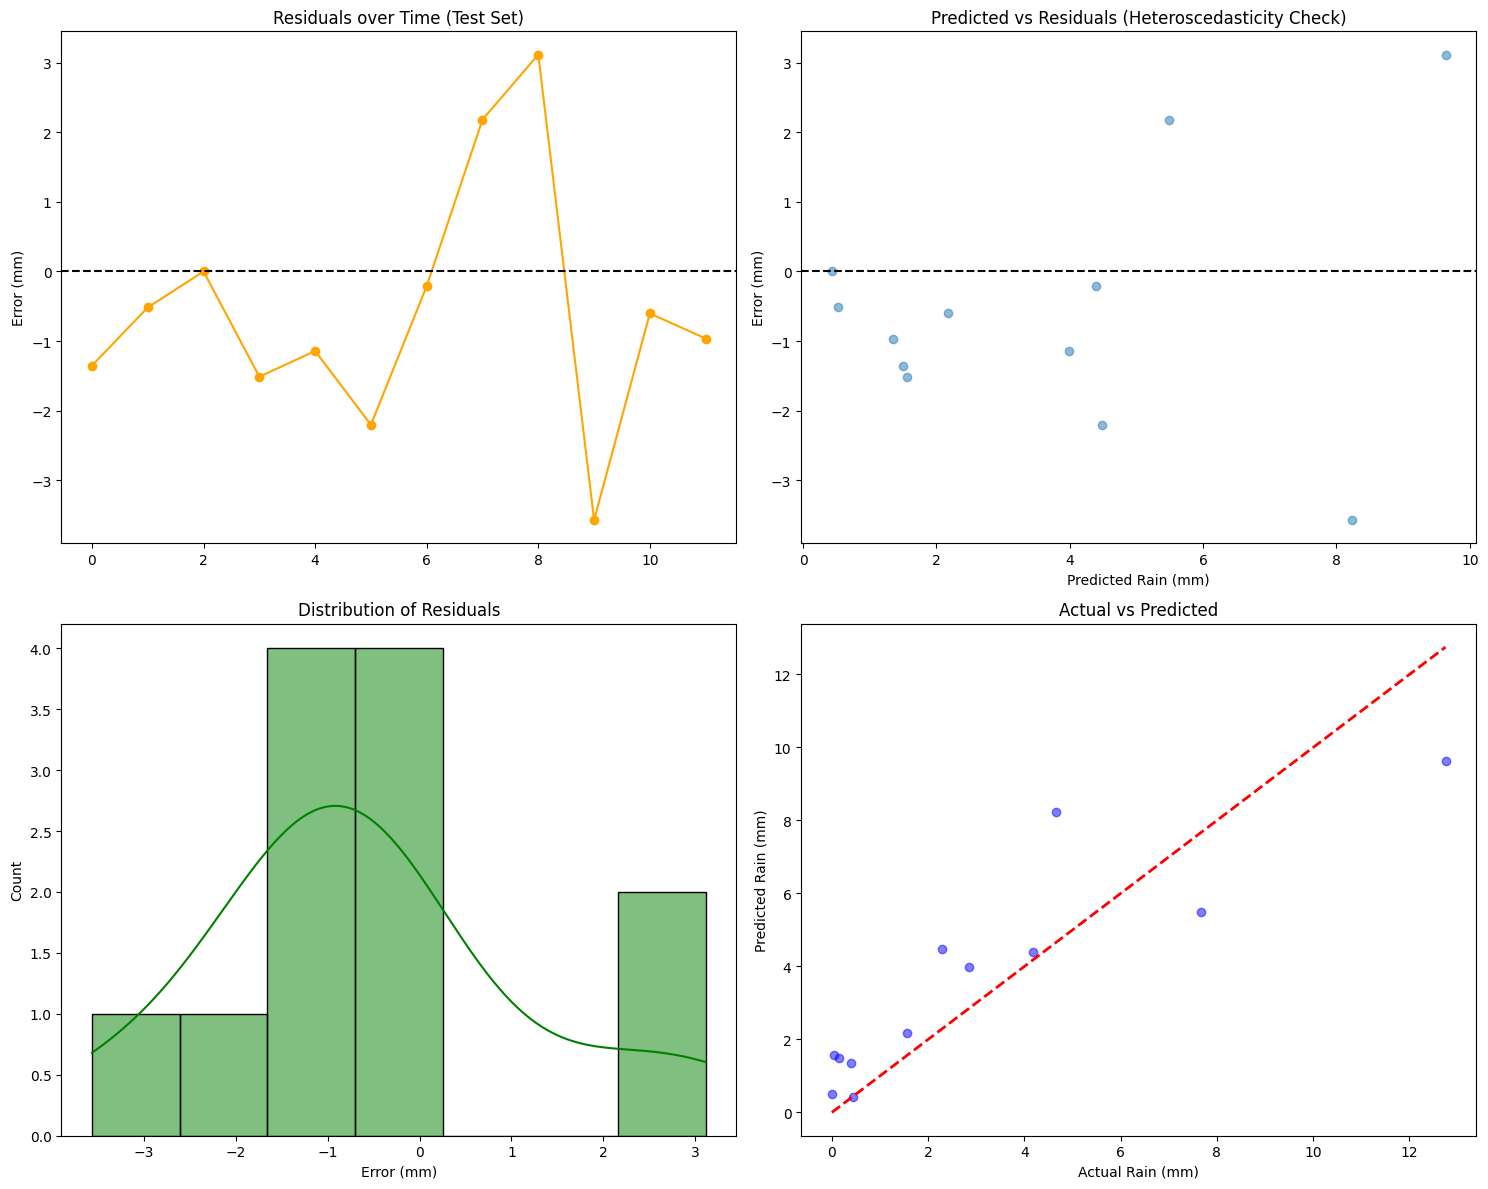

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns # ใช้เพื่อให้กราฟสวยและดูง่ายขึ้น

# 1. คำนวณ Residuals (ค่าจริง - ค่าพยากรณ์)
# residuals_val = y1_val - y_val_pred1
residuals_test = y1_test - y_final_pred1

# 2. สร้างกราฟวิเคราะห์
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# --- กราฟที่ 1: Residuals over Time (ดูว่าพลาดช่วงไหนเป็นพิเศษ) ---
axes[0, 0].plot(residuals_test.values, marker='o', linestyle='-', color='orange')
axes[0, 0].axhline(y=0, color='black', linestyle='--')
axes[0, 0].set_title('Residuals over Time (Test Set)')
axes[0, 0].set_ylabel('Error (mm)')

# --- กราฟที่ 2: Predicted vs Residuals (ดูว่าทายมาก/น้อยแล้วพลาดต่างกันไหม) ---
axes[0, 1].scatter(y_final_pred1, residuals_test, alpha=0.5)
axes[0, 1].axhline(y=0, color='black', linestyle='--')
axes[0, 1].set_title('Predicted vs Residuals (Heteroscedasticity Check)')
axes[0, 1].set_xlabel('Predicted Rain (mm)')
axes[0, 1].set_ylabel('Error (mm)')

# --- กราฟที่ 3: Distribution of Residuals (ดูว่า Error กระจายตัวแบบระฆังคว่ำไหม) ---
sns.histplot(residuals_test, kde=True, ax=axes[1, 0], color='green')
axes[1, 0].set_title('Distribution of Residuals')
axes[1, 0].set_xlabel('Error (mm)')

# --- กราฟที่ 4: Actual vs Predicted (ดูความเกาะกลุ่ม) ---
axes[1, 1].scatter(y1_test, y_final_pred1, alpha=0.5, color='blue')
axes[1, 1].plot([y1_test.min(), y1_test.max()], [y1_test.min(), y1_test.max()], 'r--', lw=2)
axes[1, 1].set_title('Actual vs Predicted')
axes[1, 1].set_xlabel('Actual Rain (mm)')
axes[1, 1].set_ylabel('Predicted Rain (mm)')

plt.tight_layout()
plt.show()

In [28]:
y_pred_original = np.expm1(y_final_pred1)
y_test_original = np.expm1(y1_test)

mse_final = mean_squared_error(y_test_original, y_pred_original)
rmse_final = np.sqrt(mse_final)
r2_final = r2_score(y_test_original, y_pred_original)

print(f"--- ผลลัพธ์ในหน่วยมิลลิเมตร (Original Scale) ---")
print(f"Mean Squared Error (MSE): {mse_final:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_final:.4f} ")
print(f"R-squared (R2): {r2_final:.4f}")

--- ผลลัพธ์ในหน่วยมิลลิเมตร (Original Scale) ---
Mean Squared Error (MSE): 9035271522.4225
Root Mean Squared Error (RMSE): 95054.0453 
R-squared (R2): 0.0025
